In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

DATA preprocessing


Training image preprocessing

In [ ]:
training_set= tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
    
)

Found 70295 files belonging to 38 classes.


Validation image preprocessing

In [ ]:
validation_set= tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
    
)

Found 17572 files belonging to 38 classes.


In [ ]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

Building model

In [ ]:
cnn= tf.keras.models.Sequential()

In [ ]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])


#Building convolution layer

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [ ]:
cnn.add(tf.keras.layers.Flatten())

In [ ]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))


In [ ]:
cnn.add(tf.keras.layers.Dense(units=38,activation='softmax')) #output layer

Compling and training phase

In [ ]:
cnn.compile(optimizer=tf.keras.optimizers.legacy.Adam(
    learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:

cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

In [ ]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 [==============================] - 224s 98ms/step - loss: 1.1587 - accuracy: 0.6502 - val_loss: 0.5178 - val_accuracy: 0.8339
Epoch 2/10
2197/2197 [==============================] - 184s 84ms/step - loss: 0.3742 - accuracy: 0.8803 - val_loss: 0.3775 - val_accuracy: 0.8780
Epoch 3/10
2197/2197 [==============================] - 184s 84ms/step - loss: 0.2196 - accuracy: 0.9282 - val_loss: 0.2672 - val_accuracy: 0.9150
Epoch 4/10
2197/2197 [==============================] - 185s 84ms/step - loss: 0.1563 - accuracy: 0.9494 - val_loss: 0.1656 - val_accuracy: 0.9456
Epoch 5/10
2197/2197 [==============================] - 185s 84ms/step - loss: 0.1127 - accuracy: 0.9628 - val_loss: 0.1654 - val_accuracy: 0.9478
Epoch 6/10
2197/2197 [==============================] - 184s 84ms/step - loss: 0.0943 - accuracy: 0.9695 - val_loss: 0.1557 - val_accuracy: 0.9509
Epoch 7/10
2197/2197 [==============================] - 184s 84ms/step - loss: 0.0730 - accuracy: 0.9761 - val_loss: 0

#Evaluating model


In [ ]:
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 [==============================] - 57s 26ms/step - loss: 0.0373 - accuracy: 0.9870
Training accuracy: 0.9870118498802185


In [ ]:
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 [==============================] - 14s 26ms/step - loss: 0.1420 - accuracy: 0.9606
Validation accuracy: 0.9605622291564941


#saving model

In [ ]:
cnn.save('trained_plant_disease_model.keras')

In [ ]:
training_history.history

{'loss': [1.158692717552185,
  0.37423011660575867,
  0.21959654986858368,
  0.15634183585643768,
  0.11268752813339233,
  0.09426694363355637,
  0.07304973900318146,
  0.06509929895401001,
  0.0584280826151371,
  0.050664909183979034],
 'accuracy': [0.6502453684806824,
  0.8802617788314819,
  0.9282310009002686,
  0.949398934841156,
  0.9627711772918701,
  0.9695426225662231,
  0.9761291742324829,
  0.9785902500152588,
  0.9812788963317871,
  0.9833558797836304],
 'val_loss': [0.5178160667419434,
  0.377450168132782,
  0.26716160774230957,
  0.16562288999557495,
  0.1653905063867569,
  0.15566174685955048,
  0.1240370124578476,
  0.15653742849826813,
  0.18915241956710815,
  0.14200638234615326],
 'val_accuracy': [0.8338834643363953,
  0.8779876828193665,
  0.9149783849716187,
  0.9455952644348145,
  0.9478147029876709,
  0.9509446620941162,
  0.959936261177063,
  0.9518552422523499,
  0.9444001913070679,
  0.9605622291564941]}

In [ ]:
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [ ]:
print(training_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


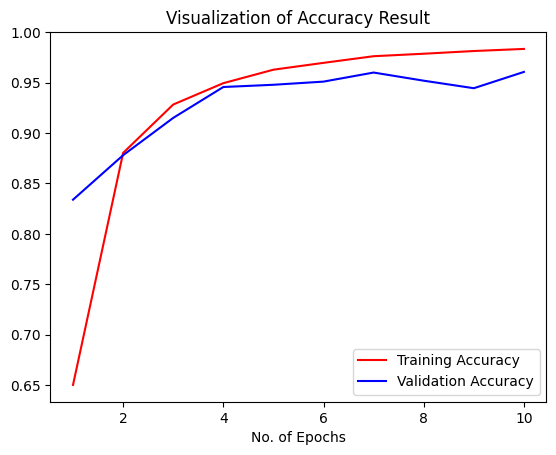

In [ ]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [ ]:
print("Validation set accuracy: {:.2f}%".format(training_history.history['val_accuracy'][-1] * 100))


Validation set accuracy: 96.06%


In [ ]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [ ]:
y_pred = cnn.predict(test_set)
y_pred,y_pred.shape


17572/17572 [==============================] - 56s 3ms/step


(array([[1.0000000e+00, 3.8549528e-09, 2.1606894e-12, ..., 5.5072064e-17,
         2.2674352e-15, 8.3647883e-15],
        [9.9997079e-01, 1.0634576e-06, 9.5407113e-09, ..., 2.3478934e-12,
         2.4512963e-12, 9.3452364e-11],
        [1.0000000e+00, 1.9194547e-10, 3.0516041e-11, ..., 1.0377540e-17,
         3.6782191e-16, 2.0988365e-14],
        ...,
        [4.3671872e-11, 6.4572761e-15, 2.8952812e-10, ..., 3.8958147e-12,
         1.8489824e-11, 9.9999988e-01],
        [3.8916188e-12, 4.0953570e-17, 2.0566461e-12, ..., 1.2054587e-13,
         6.0438248e-13, 1.0000000e+00],
        [1.8847356e-18, 7.7750462e-21, 4.4757535e-18, ..., 9.1325657e-20,
         7.3226303e-17, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [ ]:
predicted_categories = tf.argmax(y_pred, axis=1)


In [ ]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [ ]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [ ]:
Y_true=tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [ ]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.98      0.96       504
                                 Apple___Black_rot       0.99      0.99      0.99       497
                          Apple___Cedar_apple_rust       1.00      0.95      0.97       440
                                   Apple___healthy       0.97      0.94      0.95       502
                               Blueberry___healthy       0.89      1.00      0.94       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.97      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.97      0.93       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.92      0.

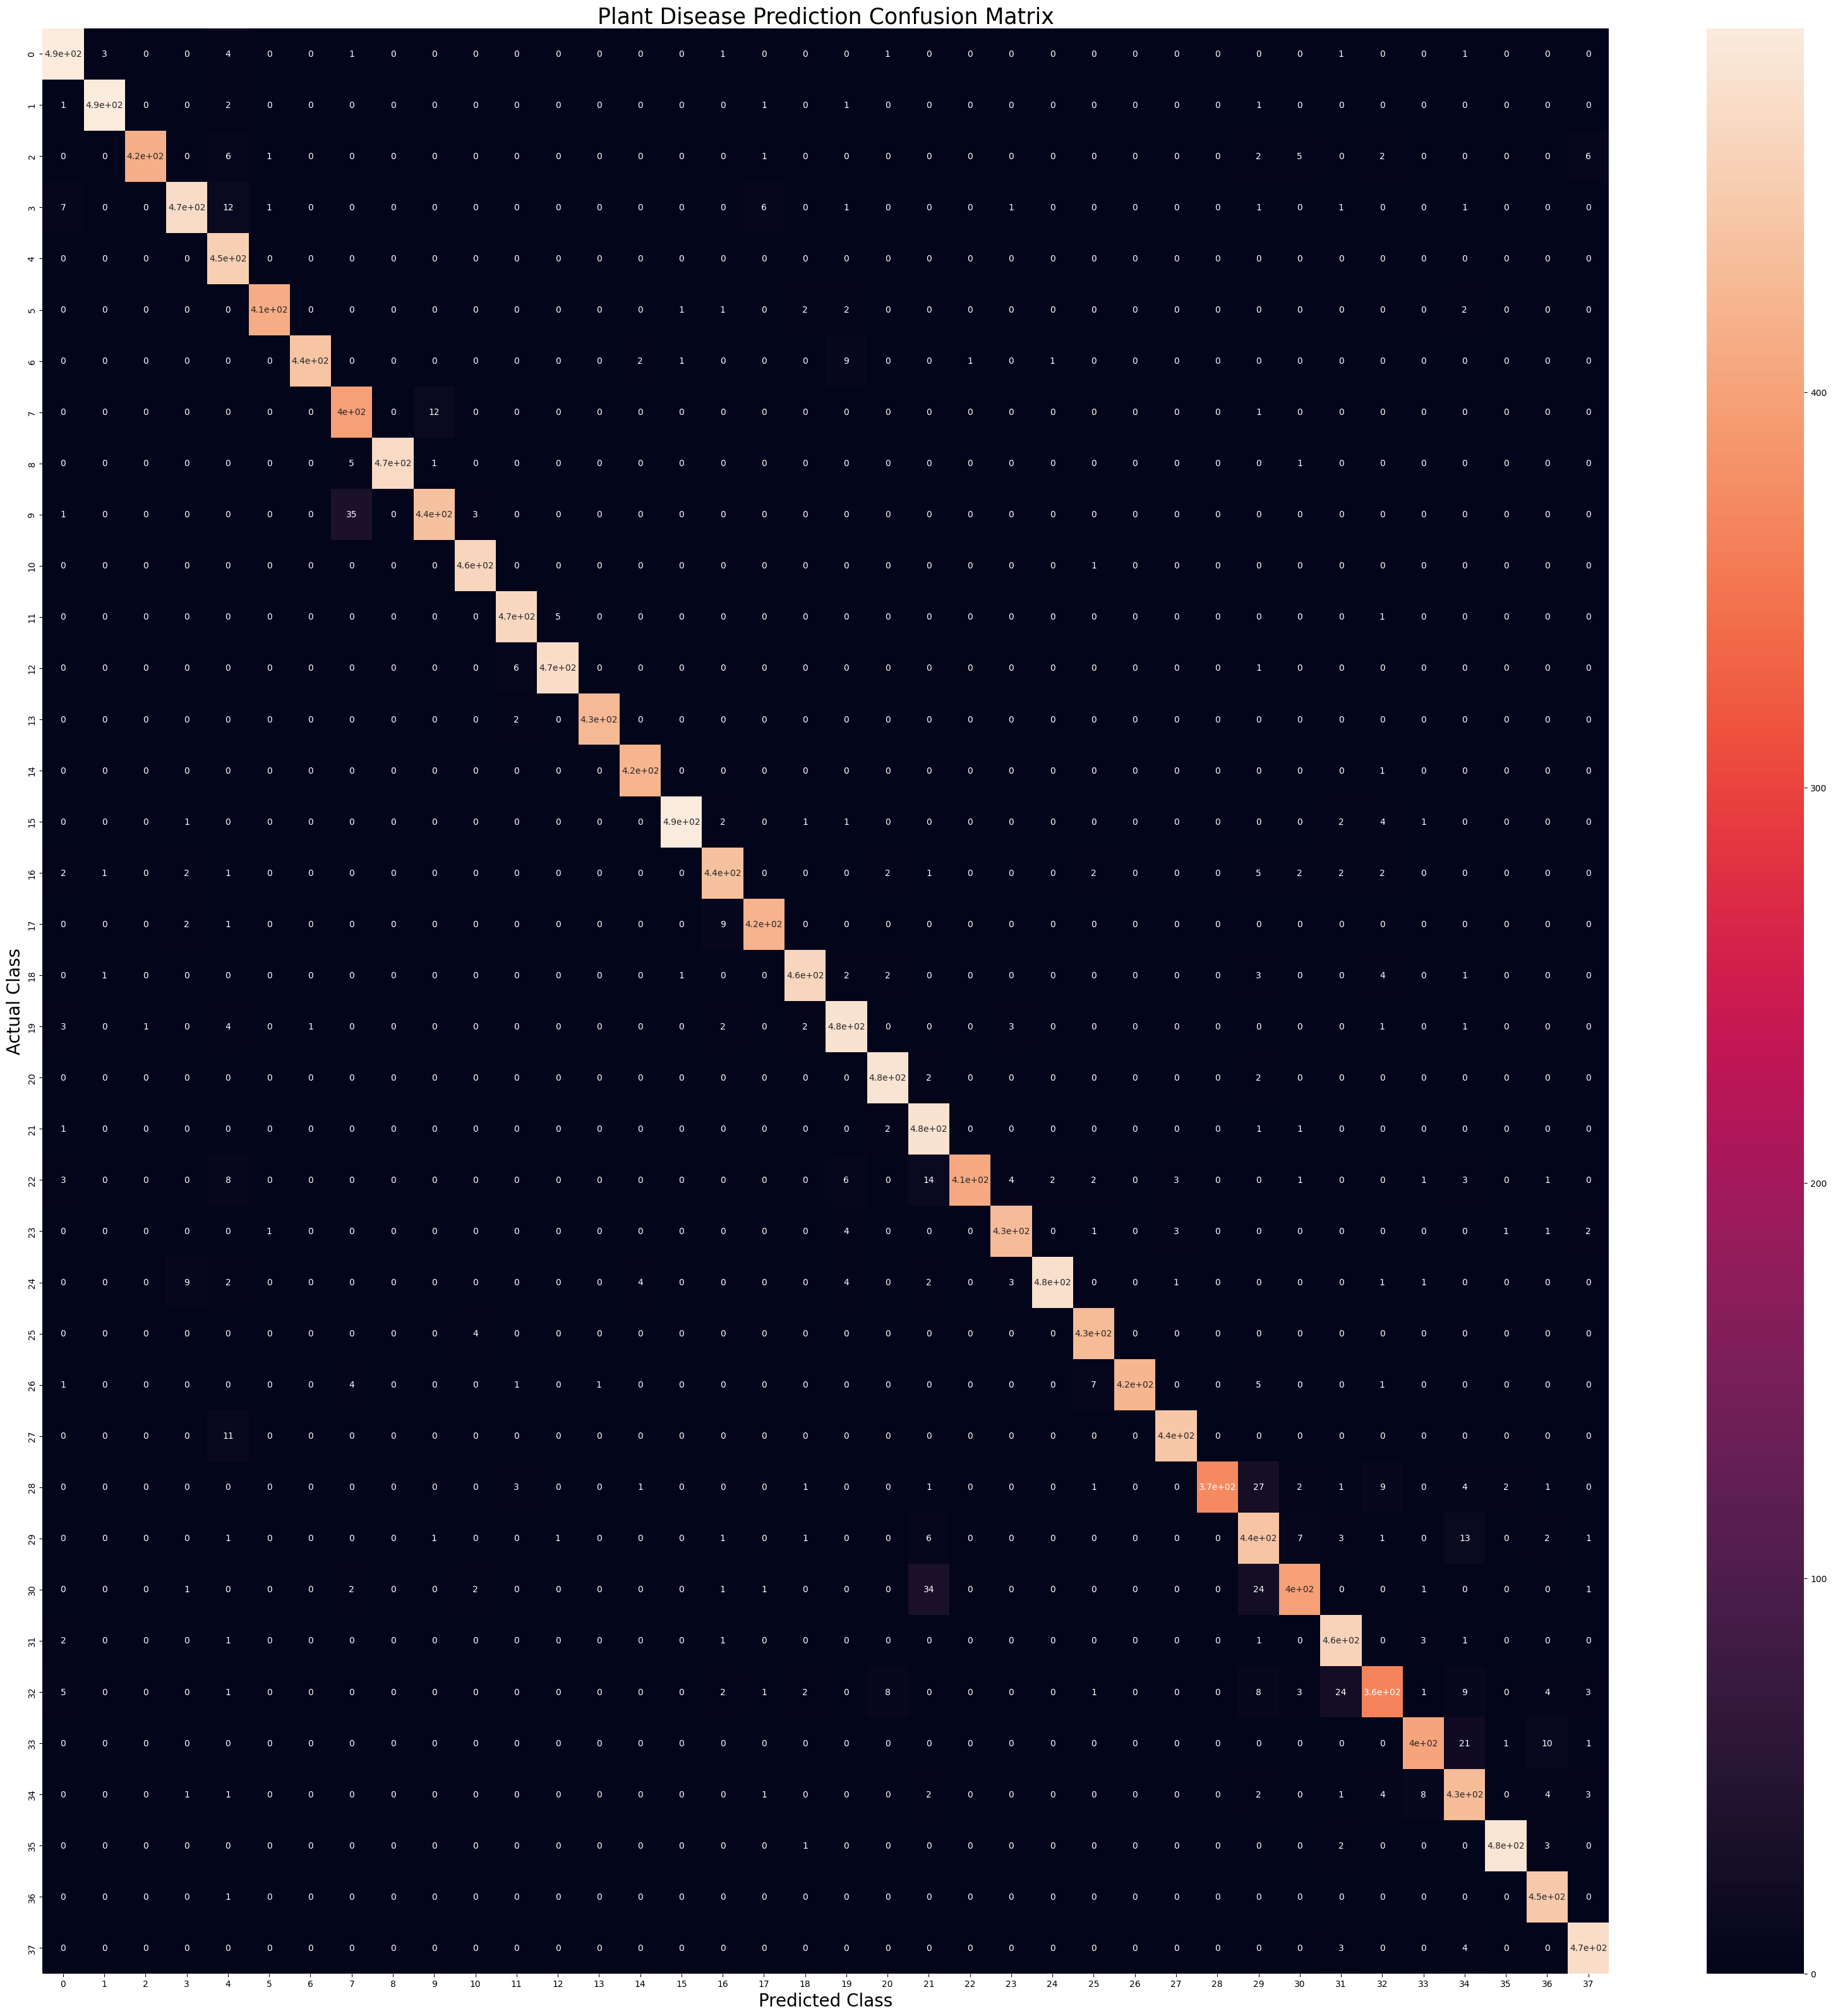

In [ ]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

**LOSS GRAPH**

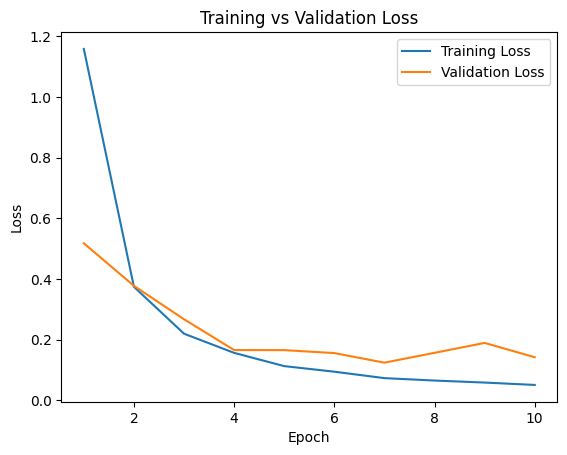

In [ ]:
epochs = [i for i in range(1, 11)]

plt.figure()
plt.plot(epochs, training_history.history['loss'], label='Training Loss')
plt.plot(epochs, training_history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



**SAMPLE PREDICTION**

1/1 [==============================] - 0s 30ms/step


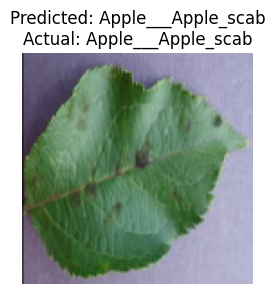

1/1 [==============================] - 0s 22ms/step


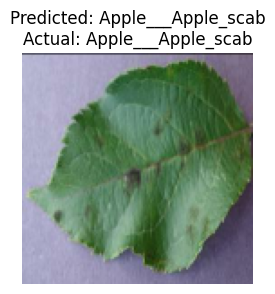

1/1 [==============================] - 0s 25ms/step


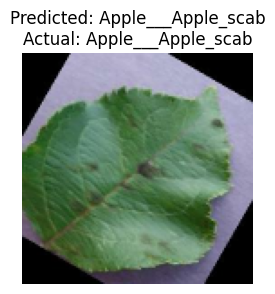

1/1 [==============================] - 0s 24ms/step


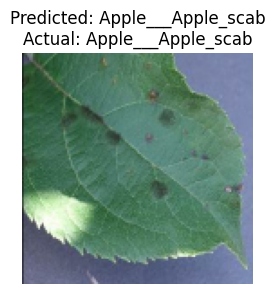

1/1 [==============================] - 0s 25ms/step


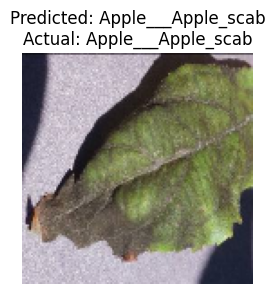

1/1 [==============================] - 0s 27ms/step


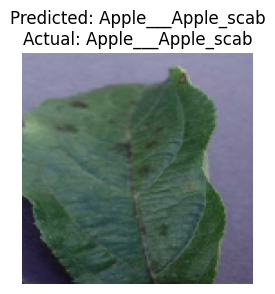

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for i, (img, label) in enumerate(test_set.take(6)):
    prediction = cnn.predict(img)  
    
    plt.figure(figsize=(3, 3))
    plt.imshow(img[0].numpy().astype("uint8"))
    
    pred_idx = np.argmax(prediction[0])
    true_idx = np.argmax(label[0])
    
    plt.title("Predicted: " + class_name[pred_idx] +
              "\nActual: " + class_name[true_idx])
    plt.axis('off')
    plt.show()

